
# Сравнение runtime для ticket routing

Сравниваются два способа запуска одной и той же LLM на задаче маршрутизации тикетов:
- baseline: `Qwen/Qwen3-1.7B` через `transformers + MPS`
- ускоренная версия: `Qwen/Qwen3-1.7B-GGUF` через `llama.cpp + Metal`

Во всех экспериментах используются один и тот же eval-набор, один и тот же prompt и одна и та же схема оценки качества.


## 1. Импорты

In [1]:
from pathlib import Path
import gc
import json
import psutil
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from llama_cpp import Llama, LlamaGrammar
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

## 2. Конфигурация эксперимента

In [ ]:
CFG = {
    'dataset_name': 'Tobi-Bueck/customer-support-tickets',
    'hf_model_name': 'Qwen/Qwen3-1.7B',
    'gguf_repo_id': 'Qwen/Qwen3-1.7B-GGUF',
    'gguf_filename': 'Qwen3-1.7B-Q8_0.gguf',
    'top_k_queues': 10,
    'samples_per_queue': 30,
    'max_input_tokens': 4096,
    'max_new_tokens': 256,
    'disable_reasoning': True,
    'seed': 42,
}

LIMITS = {
    'max_accuracy_drop_pp': 2.0,
    'max_mean_latency_ms': 1800.0,
    'max_p95_latency_ms': 2500.0,
    'min_throughput_samples_s': 0.7,
    'max_memory_mb': 8000.0,
    'max_artifact_size_mb': 4000.0,
}

ARTIFACT_DIR = Path('artifacts_runtime_compare')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('CFG')
display(pd.Series(CFG, name='value').to_frame())
print('LIMITS')
display(pd.Series(LIMITS, name='value').to_frame())


CFG


,value
dataset_name,Tobi-Bueck/customer-support-tickets
hf_model_name,Qwen/Qwen3-1.7B
gguf_repo_id,Qwen/Qwen3-1.7B-GGUF
gguf_filename,Qwen3-1.7B-Q8_0.gguf
top_k_queues,10
samples_per_queue,30
max_input_tokens,4096
max_new_tokens,256
disable_reasoning,True
seed,42


LIMITS


,value
max_accuracy_drop_pp,2.0
max_mean_latency_ms,1800.0
max_p95_latency_ms,2500.0
min_throughput_samples_s,0.7
max_memory_mb,8000.0
max_artifact_size_mb,4000.0


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def detect_device() -> str:
    return 'mps' if torch.backends.mps.is_available() else 'cpu'


def rss_mb() -> float | None:
    return psutil.Process().memory_info().rss / 1024 ** 2


def file_size_mb(path: str | Path) -> float:
    return Path(path).stat().st_size / 1024 ** 2


def state_dict_size_mb(model) -> float:
    total_bytes = 0
    for param in model.parameters():
        total_bytes += param.numel() * param.element_size()
    return total_bytes / 1024 ** 2


def normalize_label(text: str | None) -> str:
    if text is None:
        return ''
    text = text.strip().lower()
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


set_seed(CFG['seed'])
DEVICE = detect_device()
print({'device': DEVICE, 'artifact_dir': str(ARTIFACT_DIR)})

{'device': 'mps', 'artifact_dir': 'hw3/artifacts_runtime_compare'}



## 3. Ограничения

Сценарий:
- входящий тикет службы поддержки маршрутизируется в одну из support-очередей;
- требуется локальный inference на Apple Silicon;
- обучение не используется, сравниваются только inference-time решения.

Проверяемые ограничения:
- потеря accuracy относительно baseline не больше `2` п.п.;
- средняя latency не больше `1800` мс;
- `p95 latency` не больше `2500` мс;
- throughput не меньше `0.7` samples/s;
- peak process memory не больше `8000` MB;
- размер артефакта модели не больше `4000` MB.



## 4. Подготовка eval-набора

Используется один фиксированный eval-набор:
- только английские тикеты;
- `top-k` самых частых очередей;
- одинаковое число тикетов на очередь.


In [4]:
raw_df = pd.DataFrame(load_dataset(CFG['dataset_name'], split='train'))
raw_df = raw_df[raw_df['language'].fillna('').str.lower().eq('en')].copy()
raw_df['queue'] = raw_df['queue'].fillna('').astype(str).str.strip()
raw_df['subject'] = raw_df['subject'].fillna('').astype(str).str.strip()
raw_df['body'] = raw_df['body'].fillna('').astype(str).str.strip()
raw_df = raw_df[(raw_df['queue'] != '') & ((raw_df['subject'] != '') | (raw_df['body'] != ''))].copy()

queue_distribution_df = (
    raw_df['queue']
    .value_counts()
    .head(CFG['top_k_queues'])
    .rename_axis('queue')
    .reset_index(name='count')
)
queue_labels = queue_distribution_df['queue'].tolist()
queue_distribution_df.to_csv(ARTIFACT_DIR / 'queue_distribution.csv', index=False)
queue_distribution_df

,queue,count
0,Technical Support,8149
1,Product Support,5305
2,Customer Service,4269
3,IT Support,3333
4,Billing and Payments,2897
5,Returns and Exchanges,1402
6,Service Outages and Maintenance,1106
7,Sales and Pre-Sales,843
8,Human Resources,553
9,General Inquiry,404


In [5]:
sampled_parts = []
filtered_df = raw_df[raw_df['queue'].isin(queue_labels)].copy()

for queue_label in queue_labels:
    queue_part = filtered_df[filtered_df['queue'] == queue_label].copy()
    sample_size = min(len(queue_part), CFG['samples_per_queue'])
    sampled_parts.append(queue_part.sample(n=sample_size, random_state=CFG['seed']))

eval_df = pd.concat(sampled_parts, ignore_index=True)
eval_df['ticket_text'] = (
    'Subject: ' + eval_df['subject'] + '\n' +
    'Body: ' + eval_df['body'].str.replace(r'\s+', ' ', regex=True)
)
eval_df[['queue', 'subject', 'body', 'ticket_text']].to_csv(ARTIFACT_DIR / 'eval_set.csv', index=False)

print({'eval_rows': len(eval_df), 'num_queues': len(queue_labels)})
eval_df[['queue', 'subject']].head(10)


{'eval_rows': 300, 'num_queues': 10}


,queue,subject
0,Technical Support,Enhancing Bitdefender Antivirus Plus Configura...
1,Technical Support,Digital Marketing Challenge
2,Technical Support,Support for Marketing Enhancements
3,Technical Support,Enquiry on Integration Options for SAP ERP and...
4,Technical Support,Concerns About Data Analytics Tool Performance
5,Technical Support,Frequent System Crashes in Project Management ...
6,Technical Support,Issue with Magento Integration
7,Technical Support,Assistance Required for RapidMiner Integration
8,Technical Support,Enhancements in Investment Data Analytics
9,Technical Support,Assistance with MATLAB Data Analytics


## 5. Prompt и structured output

In [6]:
prompt_tokenizer = AutoTokenizer.from_pretrained(CFG['hf_model_name'])
if prompt_tokenizer.pad_token is None:
    prompt_tokenizer.pad_token = prompt_tokenizer.eos_token

QUEUE_LOOKUP = {normalize_label(label): label for label in queue_labels}
JSON_SCHEMA = {
    'type': 'object',
    'properties': {
        'queue': {
            'type': 'string',
            'enum': queue_labels,
        }
    },
    'required': ['queue'],
    'additionalProperties': False,
}

SYSTEM_PROMPT = (
    'You are a support ticket routing assistant. '
    'Choose exactly one queue from the allowed list. '
    'Do not output reasoning. Do not output <think> tags. '
    'Return JSON only in the form {"queue":"..."}.'
)

In [7]:
def render_prompt(ticket_text: str) -> str:
    allowed_queues = ', '.join(queue_labels)
    reasoning_prefix = '/no_think\n\n' if CFG['disable_reasoning'] else ''
    user_prompt = (
        reasoning_prefix +
        f'Allowed queues: {allowed_queues}\n\n'
        f'Ticket:\n{ticket_text}'
    )
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_prompt},
    ]
    try:
        return prompt_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=not CFG['disable_reasoning'],
        )
    except TypeError:
        return prompt_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )


def strip_thinking(text: str) -> str:
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL)
    return text.strip()


def parse_prediction(text: str | None) -> str | None:
    if text is None:
        return None

    text = strip_thinking(text.strip())
    if not text:
        return None

    json_candidates = [text]
    json_match = re.search(r'\{.*\}', text, flags=re.DOTALL)
    if json_match:
        json_candidates.insert(0, json_match.group(0))

    for candidate in json_candidates:
        try:
            value = json.loads(candidate)
            predicted_label = value.get('queue') if isinstance(value, dict) else None
            normalized_label = normalize_label(predicted_label)
            if normalized_label in QUEUE_LOOKUP:
                return QUEUE_LOOKUP[normalized_label]
        except Exception:
            pass

    normalized_text = normalize_label(text)
    for normalized_label, original_label in QUEUE_LOOKUP.items():
        if normalized_text == normalized_label or normalized_label in normalized_text:
            return original_label

    return None

## 6. Общие функции для оценки

In [8]:
def build_prediction_row(true_label: str, raw_output: str, latency_s: float, prompt_tokens: int | None, generated_tokens: int | None) -> dict:
    return {
        'queue': true_label,
        'raw_output': raw_output,
        'predicted_queue': parse_prediction(raw_output),
        'latency_s': latency_s,
        'prompt_tokens': prompt_tokens,
        'generated_tokens': generated_tokens,
    }


def summarize_predictions(pred_df: pd.DataFrame, runtime: str, variant: str, artifact_size_mb: float | None, peak_rss_mb: float | None, notes: str) -> dict:
    filled_pred = pred_df['predicted_queue'].fillna('__UNPARSED__')
    return {
        'runtime': runtime,
        'variant': variant,
        'samples': len(pred_df),
        'accuracy': accuracy_score(pred_df['queue'], filled_pred),
        'macro_f1': f1_score(pred_df['queue'], filled_pred, labels=queue_labels, average='macro', zero_division=0),
        'parse_success_rate': pred_df['predicted_queue'].notna().mean(),
        'mean_latency_ms': pred_df['latency_s'].mean() * 1000,
        'p95_latency_ms': pred_df['latency_s'].quantile(0.95) * 1000,
        'throughput_samples_s': len(pred_df) / pred_df['latency_s'].sum(),
        'prompt_tokens_mean': pred_df['prompt_tokens'].dropna().mean(),
        'generated_tokens_mean': pred_df['generated_tokens'].dropna().mean(),
        'artifact_size_mb': artifact_size_mb,
        'peak_process_rss_mb': peak_rss_mb,
        'notes': notes,
    }

## 7. Baseline summary и bottlenecks

In [9]:
baseline_config = AutoConfig.from_pretrained(CFG['hf_model_name'])
baseline_summary_df = pd.DataFrame([
    {'metric': 'model_name', 'value': CFG['hf_model_name']},
    {'metric': 'architecture', 'value': ', '.join(baseline_config.architectures or [])},
    {'metric': 'hidden_size', 'value': getattr(baseline_config, 'hidden_size', None)},
    {'metric': 'num_hidden_layers', 'value': getattr(baseline_config, 'num_hidden_layers', None)},
    {'metric': 'num_attention_heads', 'value': getattr(baseline_config, 'num_attention_heads', None)},
    {'metric': 'vocab_size', 'value': getattr(baseline_config, 'vocab_size', None)},
    {'metric': 'max_input_tokens', 'value': CFG['max_input_tokens']},
    {'metric': 'max_new_tokens', 'value': CFG['max_new_tokens']},
])
baseline_summary_df.to_csv(ARTIFACT_DIR / 'baseline_summary.csv', index=False)
baseline_summary_df

,metric,value
0,model_name,Qwen/Qwen3-1.7B
1,architecture,Qwen3ForCausalLM
2,hidden_size,2048
3,num_hidden_layers,28
4,num_attention_heads,16
5,vocab_size,151936
6,max_input_tokens,4096
7,max_new_tokens,256


In [10]:
bottlenecks_df = pd.DataFrame([
    {
        'bottleneck': 'full precision weights',
        'why_it_matters': 'Базовая версия использует полный state dict и поэтому требует больше памяти и дискового пространства.',
        'expected_effect_of_strategy': 'GGUF должен уменьшить размер модели и снизить memory pressure.',
    },
    {
        'bottleneck': 'general-purpose generation runtime',
        'why_it_matters': 'Базовый runtime не специализирован под локальный GGUF inference на Apple Silicon.',
        'expected_effect_of_strategy': 'llama.cpp должен дать более дешёвый inference для локального сценария.',
    },
    {
        'bottleneck': 'autoregressive decoding',
        'why_it_matters': 'Даже короткий structured output требует токен-за-токеном генерации.',
        'expected_effect_of_strategy': 'Ограничение output JSON и отключение reasoning уменьшают лишние токены.',
    },
])
bottlenecks_df.to_csv(ARTIFACT_DIR / 'bottlenecks.csv', index=False)
bottlenecks_df

,bottleneck,why_it_matters,expected_effect_of_strategy
0,full precision weights,Базовая версия использует полный state dict и ...,GGUF должен уменьшить размер модели и снизить ...
1,general-purpose generation runtime,Базовый runtime не специализирован под локальн...,llama.cpp должен дать более дешёвый inference ...
2,autoregressive decoding,Даже короткий structured output требует токен-...,Ограничение output JSON и отключение reasoning...



## 8. План реализации

Порядок реализации:
1. Зафиксировать baseline на `transformers + MPS`.
2. Зафиксировать ускоренную конфигурацию `GGUF + llama.cpp`.
3. Запустить обе конфигурации на одном eval-наборе.
4. Сравнить результаты по качеству, latency, throughput и размеру.
5. Проверить выполнение ограничений.

Критерии остановки:
- если ускоренный runtime даёт потерю по accuracy больше `2` п.п.;
- если latency или throughput не улучшаются относительно baseline;
- если размер артефакта выходит за заданный budget.


In [11]:
experiment_plan = pd.DataFrame([
    {
        'runtime': 'transformers',
        'variant': 'hf_full_precision',
        'artifact': CFG['hf_model_name'],
    },
    {
        'runtime': 'llama_cpp',
        'variant': 'gguf_q8_0',
        'artifact': CFG['gguf_filename'],
    },
])
experiment_plan

,runtime,variant,artifact
0,transformers,hf_full_precision,Qwen/Qwen3-1.7B
1,llama_cpp,gguf_q8_0,Qwen3-1.7B-Q8_0.gguf


## 9. Baseline: `transformers + MPS`

In [12]:
def run_transformers_baseline(eval_data: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    config = AutoConfig.from_pretrained(CFG['hf_model_name'])
    config.tie_word_embeddings = False

    model = AutoModelForCausalLM.from_pretrained(
        CFG['hf_model_name'],
        config=config,
        torch_dtype=torch.float16 if DEVICE == 'mps' else torch.float32,
    )
    model.to(DEVICE)
    model.eval()

    for attr in ['temperature', 'top_p', 'top_k']:
        if hasattr(model.generation_config, attr):
            setattr(model.generation_config, attr, None)
    model.generation_config.do_sample = False

    prediction_rows = []
    peak_rss_mb = rss_mb() or 0.0

    records = eval_data[['queue', 'ticket_text']].to_dict('records')
    for row in tqdm(records, desc='transformers inference'):
        prompt = render_prompt(row['ticket_text'])
        inputs = prompt_tokenizer(
            prompt,
            return_tensors='pt',
            truncation=True,
            max_length=CFG['max_input_tokens'],
        )
        prompt_tokens = int(inputs['input_ids'].shape[1])
        inputs = {name: value.to(DEVICE) for name, value in inputs.items()}

        start_time = time.perf_counter()
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=CFG['max_new_tokens'],
                do_sample=False,
                pad_token_id=prompt_tokenizer.pad_token_id,
            )
        latency_s = time.perf_counter() - start_time

        generated_ids = output[0, inputs['input_ids'].shape[1]:]
        raw_output = prompt_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        raw_output = strip_thinking(raw_output)
        prediction_rows.append(
            build_prediction_row(
                true_label=row['queue'],
                raw_output=raw_output,
                latency_s=latency_s,
                prompt_tokens=prompt_tokens,
                generated_tokens=int(generated_ids.shape[0]),
            )
        )

        current_rss_mb = rss_mb()
        if current_rss_mb is not None:
            peak_rss_mb = max(peak_rss_mb, current_rss_mb)

    pred_df = pd.DataFrame(prediction_rows)
    meta = {
        'artifact_size_mb': state_dict_size_mb(model),
        'peak_rss_mb': peak_rss_mb,
        'notes': 'baseline transformers runtime',
    }

    del model
    gc.collect()
    if DEVICE == 'mps':
        torch.mps.empty_cache()

    return pred_df, meta

## 10. Ускорение: `llama.cpp + GGUF + Metal`

In [13]:
def run_llama_cpp_runtime(eval_data: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    gguf_path = hf_hub_download(repo_id=CFG['gguf_repo_id'], filename=CFG['gguf_filename'])
    grammar = LlamaGrammar.from_json_schema(json.dumps(JSON_SCHEMA))
    llm = Llama(
        model_path=gguf_path,
        n_ctx=4096,
        n_gpu_layers=-1 if DEVICE == 'mps' else 0,
        verbose=False,
    )

    prediction_rows = []
    peak_rss_mb = rss_mb() or 0.0

    records = eval_data[['queue', 'ticket_text']].to_dict('records')
    for row in tqdm(records, desc='llama.cpp inference'):
        prompt = render_prompt(row['ticket_text'])
        prompt_tokens = len(llm.tokenize(prompt.encode('utf-8')))

        start_time = time.perf_counter()
        response = llm(
            prompt,
            max_tokens=CFG['max_new_tokens'],
            temperature=0,
            grammar=grammar,
            echo=False,
        )
        latency_s = time.perf_counter() - start_time

        raw_output = response['choices'][0]['text'].strip()
        raw_output = strip_thinking(raw_output)
        usage = response.get('usage', {})
        prediction_rows.append(
            build_prediction_row(
                true_label=row['queue'],
                raw_output=raw_output,
                latency_s=latency_s,
                prompt_tokens=usage.get('prompt_tokens', prompt_tokens),
                generated_tokens=usage.get('completion_tokens'),
            )
        )

        current_rss_mb = rss_mb()
        if current_rss_mb is not None:
            peak_rss_mb = max(peak_rss_mb, current_rss_mb)

    pred_df = pd.DataFrame(prediction_rows)
    meta = {
        'artifact_size_mb': file_size_mb(gguf_path),
        'peak_rss_mb': peak_rss_mb,
        'notes': f'llama.cpp runtime, {CFG["gguf_filename"]}',
    }

    del llm
    gc.collect()
    return pred_df, meta

## 11. Запуск экспериментов

In [14]:
results = []
failures = []
prediction_tables = {}

for plan in experiment_plan.to_dict('records'):
    runtime = plan['runtime']
    variant = plan['variant']
    print(f'Running {runtime} / {variant} ...')

    try:
        if runtime == 'transformers':
            pred_df, meta = run_transformers_baseline(eval_df)
        elif runtime == 'llama_cpp':
            pred_df, meta = run_llama_cpp_runtime(eval_df)
        else:
            raise ValueError(f'Unknown runtime: {runtime}')

        prediction_tables[variant] = pred_df.copy()
        pred_df.to_csv(ARTIFACT_DIR / f'predictions_{runtime}_{variant}.csv', index=False)
        results.append(
            summarize_predictions(
                pred_df,
                runtime=runtime,
                variant=variant,
                artifact_size_mb=meta['artifact_size_mb'],
                peak_rss_mb=meta['peak_rss_mb'],
                notes=meta['notes'],
            )
        )
    except Exception as exc:
        failures.append({'runtime': runtime, 'variant': variant, 'error': str(exc)})
        print(f'SKIPPED: {exc}')

results_df = pd.DataFrame(results)
if not results_df.empty:
    results_df = results_df.sort_values(['accuracy', 'throughput_samples_s'], ascending=[False, False]).reset_index(drop=True)

failures_df = pd.DataFrame(failures)
results_df.to_csv(ARTIFACT_DIR / 'runtime_results.csv', index=False)
failures_df.to_csv(ARTIFACT_DIR / 'runtime_failures.csv', index=False)
results_df

Running transformers / hf_full_precision ...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

transformers inference:   0%|          | 0/300 [00:00<?, ?it/s]

Running llama_cpp / gguf_q8_0 ...


llama_context: n_ctx_seq (4096) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


llama.cpp inference:   0%|          | 0/300 [00:00<?, ?it/s]

,runtime,variant,samples,accuracy,macro_f1,parse_success_rate,mean_latency_ms,p95_latency_ms,throughput_samples_s,prompt_tokens_mean,generated_tokens_mean,artifact_size_mb,peak_process_rss_mb,notes
0,llama_cpp,gguf_q8_0,300,0.20,0.153745,1.000000,268.523492,339.116775,3.724069,181.996667,7.186667,1749.444977,3064.203125,"llama.cpp runtime, Qwen3-1.7B-Q8_0.gguf"
1,transformers,hf_full_precision,300,0.19,0.142861,0.943333,389.761105,479.650320,2.565674,181.996667,8.093333,3875.236328,1407.109375,baseline transformers runtime


In [15]:
failures_df

""


## 12. Сравнение с baseline

In [16]:
if results_df.empty:
    comparison_df = pd.DataFrame()
else:
    baseline_row = results_df[results_df['runtime'] == 'transformers'].head(1)
    if baseline_row.empty:
        comparison_df = results_df.copy()
    else:
        baseline = baseline_row.iloc[0]
        comparison_df = results_df.copy()
        comparison_df['accuracy_drop_pp'] = (baseline['accuracy'] - comparison_df['accuracy']) * 100
        comparison_df['speedup_vs_baseline'] = baseline['mean_latency_ms'] / comparison_df['mean_latency_ms']
        comparison_df['throughput_gain_vs_baseline'] = comparison_df['throughput_samples_s'] / baseline['throughput_samples_s']

comparison_df.to_csv(ARTIFACT_DIR / 'selected_comparison.csv', index=False)
comparison_df

,runtime,variant,samples,accuracy,macro_f1,parse_success_rate,mean_latency_ms,p95_latency_ms,throughput_samples_s,prompt_tokens_mean,generated_tokens_mean,artifact_size_mb,peak_process_rss_mb,notes,accuracy_drop_pp,speedup_vs_baseline,throughput_gain_vs_baseline
0,llama_cpp,gguf_q8_0,300,0.20,0.153745,1.000000,268.523492,339.116775,3.724069,181.996667,7.186667,1749.444977,3064.203125,"llama.cpp runtime, Qwen3-1.7B-Q8_0.gguf",-1.0,1.451497,1.451497
1,transformers,hf_full_precision,300,0.19,0.142861,0.943333,389.761105,479.650320,2.565674,181.996667,8.093333,3875.236328,1407.109375,baseline transformers runtime,0.0,1.000000,1.000000


## 13. Проверка ограничений

In [20]:
if comparison_df.empty:
    limits_check_df = pd.DataFrame()
else:
    limits_check_df = comparison_df.copy()
    limits_check_df['meets_accuracy_budget'] = limits_check_df['accuracy_drop_pp'] <= LIMITS['max_accuracy_drop_pp']
    limits_check_df['meets_mean_latency_budget'] = limits_check_df['mean_latency_ms'] <= LIMITS['max_mean_latency_ms']
    limits_check_df['meets_p95_latency_budget'] = limits_check_df['p95_latency_ms'] <= LIMITS['max_p95_latency_ms']
    limits_check_df['meets_throughput_budget'] = limits_check_df['throughput_samples_s'] >= LIMITS['min_throughput_samples_s']
    limits_check_df['meets_memory_budget'] = limits_check_df['peak_process_rss_mb'] <= LIMITS['max_memory_mb']
    limits_check_df['meets_size_budget'] = limits_check_df['artifact_size_mb'] <= LIMITS['max_artifact_size_mb']
    limits_check_df['overall_pass'] = (
        limits_check_df['meets_accuracy_budget']
        & limits_check_df['meets_mean_latency_budget']
        & limits_check_df['meets_p95_latency_budget']
        & limits_check_df['meets_throughput_budget']
        & limits_check_df['meets_memory_budget']
        & limits_check_df['meets_size_budget']
    )

limits_check_df.to_csv(ARTIFACT_DIR / 'limits_check.csv', index=False)
limits_check_df.T

,0,1
runtime,llama_cpp,transformers
variant,gguf_q8_0,hf_full_precision
samples,300,300
accuracy,0.2,0.19
macro_f1,0.153745,0.142861
parse_success_rate,1.0,0.943333
mean_latency_ms,268.523492,389.761105
p95_latency_ms,339.116775,479.65032
throughput_samples_s,3.724069,2.565674
prompt_tokens_mean,181.996667,181.996667


## 14. Примеры предсказаний

In [21]:
for variant_name, pred_table in prediction_tables.items():
    print('\n' + '=' * 80)
    print(variant_name)
    display(pred_table[['queue', 'predicted_queue', 'raw_output', 'latency_s']].head(5))



hf_full_precision


,queue,predicted_queue,raw_output,latency_s
0,Technical Support,Product Support,"{""queue"":""Product Support""}",0.634722
1,Technical Support,Product Support,"{""queue"":""Product Support""}",0.358077
2,Technical Support,Product Support,"{""queue"":""Product Support""}",0.377534
3,Technical Support,Product Support,"{""queue"":""Product Support""}",0.408109
4,Technical Support,Technical Support,"{""queue"":""Technical Support""}",0.380954



gguf_q8_0


,queue,predicted_queue,raw_output,latency_s
0,Technical Support,Product Support,"{""queue"":""Product Support""}",0.281832
1,Technical Support,General Inquiry,"{""queue"":""General Inquiry""}",0.188438
2,Technical Support,Product Support,"{""queue"":""Product Support""}",0.215927
3,Technical Support,Product Support,"{""queue"":""Product Support""}",0.243548
4,Technical Support,Technical Support,"{""queue"":""Technical Support""}",0.228718


## 15. Графики

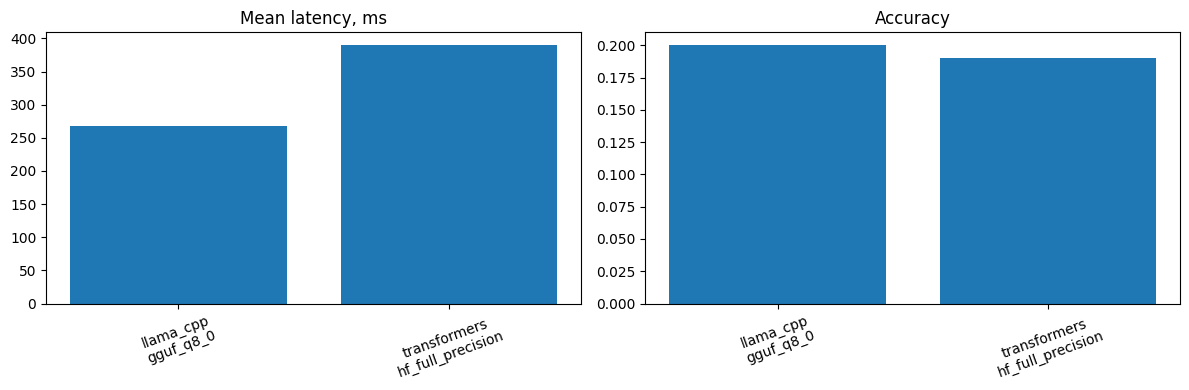

In [22]:
if not comparison_df.empty:
    plot_df = comparison_df.copy()
    plot_df['label'] = plot_df['runtime'] + '\n' + plot_df['variant']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(plot_df['label'], plot_df['mean_latency_ms'])
    axes[0].set_title('Mean latency, ms')
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].bar(plot_df['label'], plot_df['accuracy'])
    axes[1].set_title('Accuracy')
    axes[1].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / 'runtime_plots.png', dpi=160, bbox_inches='tight')
    plt.show()